In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import qubo_utils

In [ ]:
edges = [
    (0,1),
    (0,2),
    (1,2),
    (1,3),
    (2,3),
    (2,4)
]

costs = [2,4,3,2,5,1]

nodes = [0,1,2,3,4]

targets = {
    0: 1,
    1: 0,
    2: 0,
    3: -1,
    4: 0
}

In [ ]:
penalty_sets = [
    (10,5),
    (20,10),
    (50,20),
    (80,25),
    (200,80)
]

In [ ]:
all_results = []

for P1, P2 in penalty_sets:

    print("\n============================")
    print(f"P1 = {P1}, P2 = {P2}")
    print("============================")

    Q = qubo_utils.build_Q(
        costs,
        edges,
        nodes,
        targets,
        P1=P1,
        P2=P2
    )

    results = []

    n = len(costs)

    for bits in itertools.product([0,1], repeat=n):

        x = np.array(bits)

        energy = x.T @ Q @ x

        selected_edges = [
            edges[i]
            for i,b in enumerate(bits)
            if b == 1
        ]

        path_cost = sum(
            costs[i]
            for i,b in enumerate(bits)
            if b == 1
        )

        valid = qubo_utils.check_constraints(
            bits,
            edges,
            nodes,
            targets
        )

        results.append({
            "bits": bits,
            "energy": energy,
            "path_cost": path_cost,
            "valid": valid
        })

    valid_results = [r for r in results if r["valid"]]

    best = min(valid_results, key=lambda r: r["energy"])

    print("Best valid energy:", best["energy"])
    print("Best valid bits:", best["bits"])

    edge_names = {
        (0,1): "AB",
        (0,2): "AC",
        (1,2): "BC",
        (1,3): "BD",
        (2,3): "CD",
        (2,4): "CE"
    }

    selected_edges = [
        edges[i]
        for i,b in enumerate(best["bits"])
        if b == 1
    ]

    path = " -> ".join(edge_names[e] for e in selected_edges)

    print("Best path:", path)

    all_results.append({
        "P1": P1,
        "P2": P2,
        "energy": best["energy"]
    })


P1 = 10, P2 = 5
Best valid energy: -16.0
Best valid bits: (1, 0, 0, 1, 0, 0)
Best path: AB -> BD

P1 = 20, P2 = 10
Best valid energy: -36.0
Best valid bits: (1, 0, 0, 1, 0, 0)
Best path: AB -> BD

P1 = 50, P2 = 20
Best valid energy: -96.0
Best valid bits: (1, 0, 0, 1, 0, 0)
Best path: AB -> BD

P1 = 80, P2 = 25
Best valid energy: -156.0
Best valid bits: (1, 0, 0, 1, 0, 0)
Best path: AB -> BD

P1 = 200, P2 = 80
Best valid energy: -396.0
Best valid bits: (1, 0, 0, 1, 0, 0)
Best path: AB -> BD


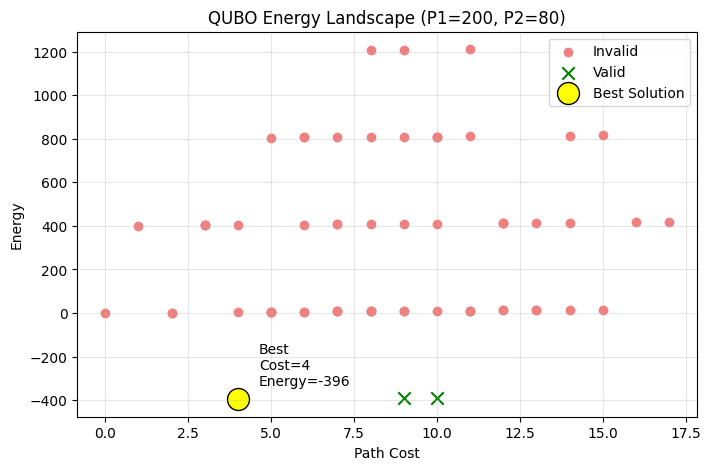

In [ ]:
    invalid_x = [r["path_cost"] for r in results if not r["valid"]]
    invalid_y = [r["energy"] for r in results if not r["valid"]]

    valid_x = [r["path_cost"] for r in results if r["valid"]]
    valid_y = [r["energy"] for r in results if r["valid"]]

    plt.figure(figsize=(8,5))

    plt.scatter(
        invalid_x,
        invalid_y,
        c="lightcoral",
        label="Invalid"
    )

    plt.scatter(
        valid_x,
        valid_y,
        c="green",
        marker="x",
        s=80,
        label="Valid"
    )

    plt.scatter(
        best["path_cost"],
        best["energy"],
        c="yellow",
        edgecolors="black",
        s=250,
        label="Best Solution"
    )

    plt.annotate(
        f"Best\nCost={best['path_cost']}\nEnergy={best['energy']:.0f}",
        (best["path_cost"], best["energy"]),
        textcoords="offset points",
        xytext=(15,10)
    )

    plt.title(f"QUBO Energy Landscape (P1={P1}, P2={P2})")

    plt.xlabel("Path Cost")
    plt.ylabel("Energy")

    plt.legend()

    plt.grid(alpha=0.3)

    plt.show()

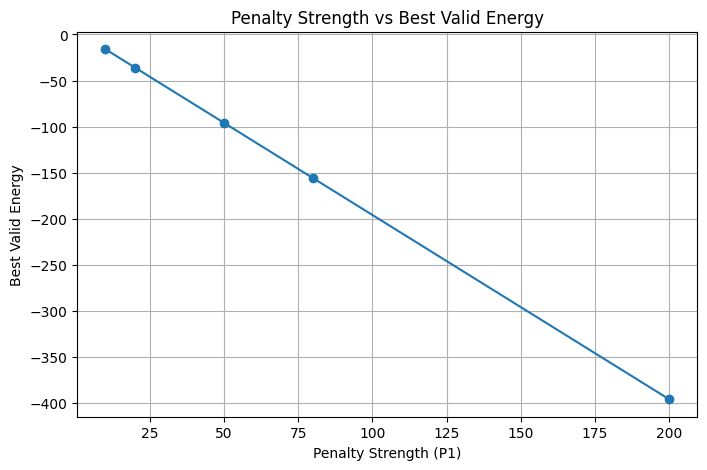

In [ ]:
import matplotlib.pyplot as plt

P1_vals = [r["P1"] for r in all_results]
energies = [r["energy"] for r in all_results]

plt.figure(figsize=(8,5))

plt.plot(P1_vals, energies, marker='o')

plt.title("Penalty Strength vs Best Valid Energy")

plt.xlabel("Penalty Strength (P1)")
plt.ylabel("Best Valid Energy")

plt.grid(True)

plt.show()

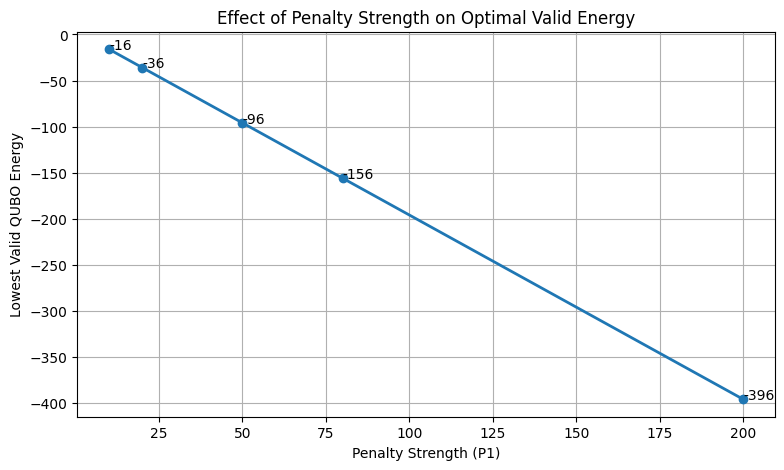

In [ ]:
import matplotlib.pyplot as plt

P1_vals = [r["P1"] for r in all_results]
energies = [r["energy"] for r in all_results]

plt.figure(figsize=(9,5))

plt.plot(
    P1_vals,
    energies,
    marker='o',
    linewidth=2
)

for x, y in zip(P1_vals, energies):
    plt.text(x, y, f"{y:.0f}")

plt.title("Effect of Penalty Strength on Optimal Valid Energy")

plt.xlabel("Penalty Strength (P1)")
plt.ylabel("Lowest Valid QUBO Energy")

plt.grid(True)

plt.show()

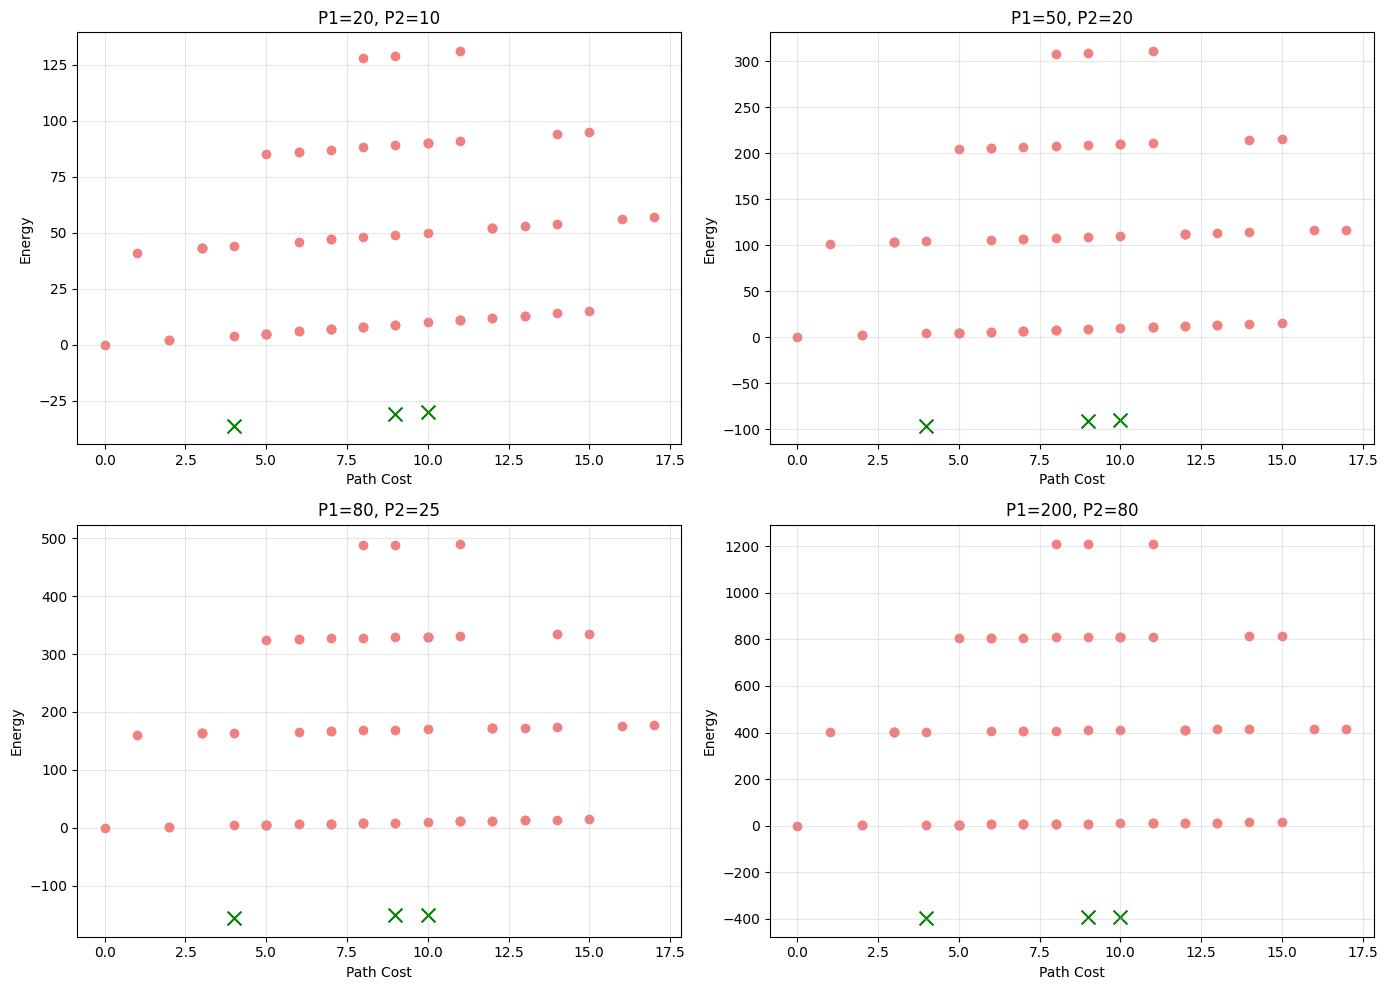

In [ ]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

penalty_configs = [
    (20,10),
    (50,20),
    (80,25),
    (200,80)
]

fig, axes = plt.subplots(2, 2, figsize=(14,10))

axes = axes.flatten()

for idx, (P1, P2) in enumerate(penalty_configs):

    Q = qubo_utils.build_Q(
        costs,
        edges,
        nodes,
        targets,
        P1=P1,
        P2=P2
    )

    results = []

    for bits in itertools.product([0,1], repeat=len(costs)):

        x = np.array(bits)

        energy = x.T @ Q @ x

        selected_edges = [
            edges[i]
            for i,b in enumerate(bits)
            if b == 1
        ]

        path_cost = sum(
            costs[i]
            for i,b in enumerate(bits)
            if b == 1
        )

        valid = qubo_utils.is_valid_path(
        selected_edges,
        targets
        )
        

        results.append({
            "energy": energy,
            "path_cost": path_cost,
            "valid": valid
        })

    invalid_x = [r["path_cost"] for r in results if not r["valid"]]
    invalid_y = [r["energy"] for r in results if not r["valid"]]

    valid_x = [r["path_cost"] for r in results if r["valid"]]
    valid_y = [r["energy"] for r in results if r["valid"]]

    ax = axes[idx]

    ax.scatter(
        invalid_x,
        invalid_y,
        c="lightcoral",
        label="Invalid"
    )

    ax.scatter(
        valid_x,
        valid_y,
        c="green",
        marker="x",
        s=100,
        label="Valid"
    )

    ax.set_title(f"P1={P1}, P2={P2}")

    ax.set_xlabel("Path Cost")
    ax.set_ylabel("Energy")

    ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()

Observation 

As the penalty strengths increase, invalid solutions are pushed to significantly higher energy values, creating a stronger separation between valid and invalid states in the QUBO energy landscape. 

For smaller penalties, valid and invalid configurations are closer together, which may make it difficult for QAOA to distinguish feasible solutions. 

For very large penalties, the valid states become relatively compressed compared to the overall energy scale, causing the landscape to become dominated by penalty contributions. This may reduce the relative distinction among valid solutions, which aligns with the mentor’s observation regarding QAOA sensitivity.